In [1]:
import os, re
import numpy as np
import scanpy as sc
from os.path import join
import pandas as pd

import sys
import scipy.io as sio
import scipy.sparse as sps
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from spamosaic.framework import SpaMosaic
import spamosaic.utils as utls
from spamosaic.preprocessing import RNA_preprocess, ADT_preprocess, Epigenome_preprocess, harmony

os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8' 

In [2]:
data_dir = '../../../data/processed/Mux-VisiumHD-HE'

ad_mux_rna = sc.read_h5ad(join(data_dir, 'Mux/ad_rna.h5ad'))
ad_mux_atac = sc.read_h5ad(join(data_dir, 'Mux/ad_atac.h5ad'))

ad_vhd_rna = sc.read_h5ad(join(data_dir, 'VisiumHD/ad_rna.h5ad'))
ad_vhe_rna = sc.read_h5ad(join(data_dir, 'VisiumHE/ad_rna.h5ad')) 

input_dict = { 
    'rna':  [ad_mux_rna,  ad_vhd_rna,  ad_vhe_rna],
    'atac':  [ad_mux_atac, None       , None],
}

input_key = 'dimred_bc'
batch_key = 'Slice'

In [3]:
cache_dir = './cache_dir/Mux-VisiumHD-HE'
df_cca = pd.read_csv(join(cache_dir, 'cca_coordinates.csv'), index_col=0)    # exported using seurat integration pipeline 
for adx in input_dict['rna']:
    adx.obsm[input_key] = df_cca.loc[adx.obs_names].values

Epigenome_preprocess(input_dict['atac'], batch_corr=False, n_peak=50000, batch_key=batch_key, key=input_key, return_hvf=False)   

In [4]:
model = SpaMosaic(
    modBatch_dict=input_dict, input_key=input_key,
    batch_key=batch_key, 
    intra_knns=10, inter_knn_base=10, w_g=0.8,
    smooth_input=True, smooth_L=1, inter_auto_knn=True, inter_auto_thr=0.8,
    rmv_outlier=True, contamination=.5,
    seed=1234, 
    device='cuda:0'
)

model.train(net='wlgcn', lr=0.01, T=0.01, n_epochs=100)

batch0: ['rna', 'atac']
batch1: ['rna']
batch2: ['rna']
------Calculating spatial graph...
The graph contains 96860 edges, 9686 cells.
10.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 989170 edges, 98917 cells.
10.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 27020 edges, 2702 cells.
10.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 96860 edges, 9686 cells.
10.0000 neighbors per cell on average.
Searching MNN within rna
Finding MNN between (mux, hd) using KNN (10, 1)
==> Filtered 2800 from 5602 (49.98%)
Finding MNN between (mux, he) using KNN (2, 10)
==> Filtered 1076 from 2153 (49.98%)
Number of mnn pairs for rna:3879
Searching MNN within atac
Number of mnn pairs for atac:0


100%|███████████████████████████████████████████████████████████████████████████████████| 100/100 [00:26<00:00,  3.74it/s]


In [5]:
ad_embs = model.infer_emb(input_dict, emb_key='emb', final_latent_key='merged_emb')
ad_mosaic = sc.concat(ad_embs)
ad_mosaic = utls.get_umap(ad_mosaic, use_reps=['merged_emb'])

ad_mosaic = utls.clustering(ad_mosaic, 18, 'merged_emb', algo='mclust', key='mclust')
utls.split_adata_ob(ad_embs, ad_mosaic, ob='obs', key='mclust')

/home/yanxh/anaconda3/envs/spamosaic-env/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.0.0
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


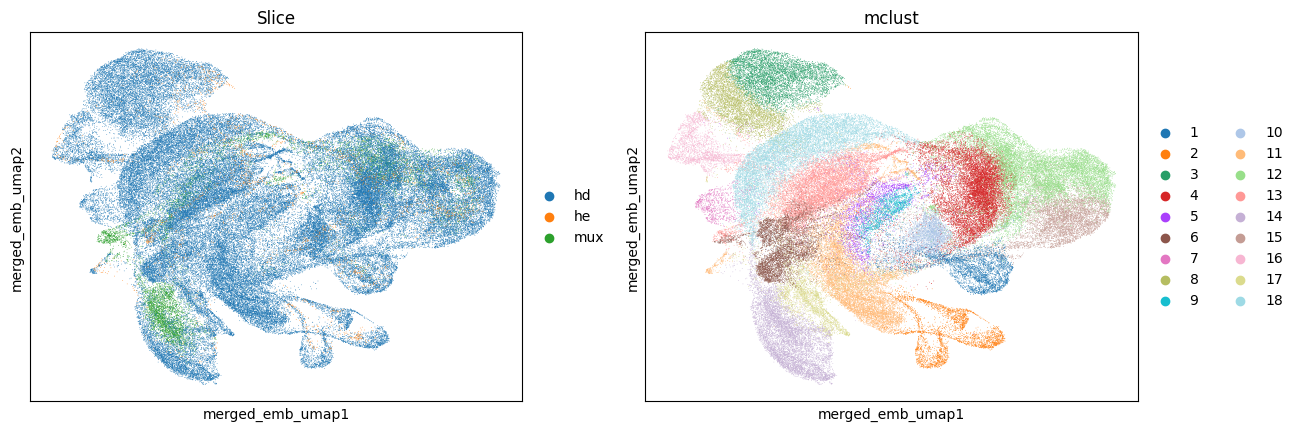

In [11]:
utls.plot_basis(ad_mosaic, 'merged_emb_umap', [batch_key, 'mclust'])

In [12]:
# make the color of clusters consistent across sections
def unify_colors(ads, ad_ref, color):
    cat2color = dict(zip(ad_ref.obs[color].cat.categories, ad_ref.uns[f'{color}_colors']))
    for ad in ads:
        ad.obs[color] = ad.obs[color].astype('category')
        ad.uns[f'{color}_colors'] = [ 
            cat2color.get(cat, '#000000')
            for cat in ad.obs[color].cat.categories
        ]

unify_colors(ad_embs, ad_mosaic, 'mclust')

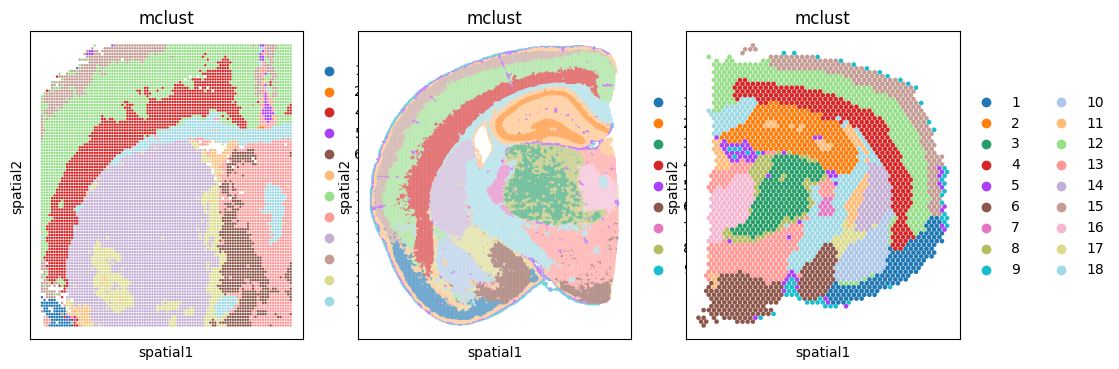

In [13]:
_, axes = plt.subplots(1, len(ad_embs), figsize=(4*len(ad_embs), 4))
for i,adx in enumerate(ad_embs):
    utls.plot_basis(adx, 'spatial', 'mclust', ax=axes[i], show=False)

plt.show()

In [14]:
fig_dir = f'../../../results/embeddings/SpaMosaic/Mux-VisiumHD-HE'
os.makedirs(fig_dir, exist_ok=True)

df = pd.DataFrame(ad_mosaic.obsm['merged_emb'], index=ad_mosaic.obs_names)
df.to_csv(join(fig_dir, 'df_emb.csv'))